# Phase 2 — Fine-tune on Nepali Words
## VGG16+BiLSTM+CTC | Nepali typed-font dataset

**Prerequisites:**
- `crnn_hindi_best.pth` from Phase 1 must be in `/kaggle/working/`
- `vocab.txt` from Phase 1 must be in `/kaggle/working/`
- Nepali dataset uploaded to Kaggle input (images folder + labels .txt file)

**What this notebook does:**
1. Loads Phase 1 checkpoint
2. Parses Nepali labels, strips BOM, splits by word index (not image) to avoid data leakage
3. Extends vocabulary if Nepali has new characters (unlikely but checked)
4. Fine-tunes with low LR on CNN, normal LR on RNN/FC
5. Saves checkpoint every epoch (10 epochs total)
6. Plots curves and runs inference on sample images
7. Simple Gradio UI for manual testing in the Kaggle session

In [1]:
# ── CELL 1: Check GPU ─────────────────────────────────────────────
import torch
print('CUDA available :', torch.cuda.is_available())
print('GPU            :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')
print('PyTorch        :', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device         :', DEVICE)

CUDA available : True
GPU            : Tesla T4
PyTorch        : 2.10.0+cu128
Device         : cuda


In [3]:
# ── CELL 2: Configuration ─────────────────────────────────────────
# EDIT THESE to match your Kaggle dataset paths
from pathlib import Path

# --- INPUT PATHS ---
# Folder containing all word*.png images
IMAGE_DIR    = Path('/kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images')   # <-- adjust
# The tab-separated txt file: filename\tlabel
LABELS_TXT   = Path('/kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/labels.txt')  # <-- adjust

# Phase 1 outputs (should already be in /kaggle/working from Phase 1 run)
PHASE1_MODEL = Path('/kaggle/input/models/kritakhere/handwritten-hindi-word-ocr-vcc16/pytorch/v1/1/crnn_hindi_best.pth')
PHASE1_VOCAB = Path('/kaggle/input/models/kritakhere/handwritten-hindi-word-ocr-vcc16/pytorch/v1/1/vocab.txt')

# --- OUTPUT PATHS ---
OUTPUT_DIR  = Path('/kaggle/working')
CKPT_DIR    = OUTPUT_DIR / 'checkpoints_phase2'
MODEL_PATH  = OUTPUT_DIR / 'crnn_nepali_best.pth'
VOCAB2_PATH = OUTPUT_DIR / 'vocab_phase2.txt'
CKPT_DIR.mkdir(exist_ok=True)

# --- TRAINING CONFIG ---
IMG_HEIGHT  = 64    # keep same as Phase 1 — images are 64px, upscaling adds no real info
IMG_WIDTH   = 256
BATCH_SIZE  = 64
EPOCHS      = 20
MAX_LABEL_LEN = 20

# Learning rates — LOW for CNN (preserve Phase 1 features), normal for RNN/FC
LR_CNN = 1e-6
LR_RNN = 1e-4
LR_FC  = 1e-4

# Train/val split ratio (split by WORD INDEX, not image, to prevent leakage)
VAL_RATIO = 0.15

print('Configuration ready.')
print(f'Phase 1 model exists : {PHASE1_MODEL.exists()}')
print(f'Phase 1 vocab exists : {PHASE1_VOCAB.exists()}')
print(f'Image dir exists     : {IMAGE_DIR.exists()}')
print(f'Labels txt exists    : {LABELS_TXT.exists()}')

Configuration ready.
Phase 1 model exists : True
Phase 1 vocab exists : True
Image dir exists     : True
Labels txt exists    : True


In [4]:
# ── CELL 3: Imports ───────────────────────────────────────────────
import os, random, time
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import warnings
warnings.filterwarnings('ignore')
print('Imports done.')

Imports done.


In [5]:
# ── CELL 4: Parse labels + split by word index ───────────────────
#
# IMPORTANT: We split by word index (the NNNNN in wordNNNNN_fontX.png)
# NOT by individual image. If we split by image, the model sees
# 'आदित' in font0 during training and 'आदित' in font11 during
# validation — that's data leakage, giving fake high val accuracy.

def parse_labels(txt_path, image_dir):
    """Parse tab-separated labels file. Returns list of (img_path, label, word_idx)."""
    pairs = []
    skipped_missing = 0
    skipped_empty   = 0
    bom_stripped    = 0

    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line.strip():
                continue
            parts = line.split('\t')
            if len(parts) < 2:
                skipped_empty += 1
                continue

            filename = parts[0].strip()
            label    = parts[1].strip()

            # Strip BOM (\ufeff) that appears on some labels
            if label.startswith('\ufeff'):
                label = label[1:]
                bom_stripped += 1

            if not label:
                skipped_empty += 1
                continue

            img_path = image_dir / filename
            if not img_path.exists():
                skipped_missing += 1
                continue

            # Extract word index from filename: word00000_font3.png -> 0
            stem = Path(filename).stem  # word00000_font3
            try:
                word_idx = int(stem.split('_font')[0].replace('word', ''))
            except:
                word_idx = -1

            pairs.append((str(img_path), label, word_idx))

    print(f'Loaded     : {len(pairs)} valid pairs')
    print(f'BOM fixed  : {bom_stripped}')
    print(f'Missing    : {skipped_missing} images not found')
    print(f'Empty      : {skipped_empty} empty labels')
    return pairs


all_pairs = parse_labels(LABELS_TXT, IMAGE_DIR)

# Get unique word indices and split 85/15
unique_word_ids = sorted(set(p[2] for p in all_pairs))
random.seed(42)
random.shuffle(unique_word_ids)

split_point  = int(len(unique_word_ids) * (1 - VAL_RATIO))
train_ids    = set(unique_word_ids[:split_point])
val_ids      = set(unique_word_ids[split_point:])

train_pairs  = [(p, l) for p, l, w in all_pairs if w in train_ids]
val_pairs    = [(p, l) for p, l, w in all_pairs if w in val_ids]

print(f'\nUnique words : {len(unique_word_ids)}')
print(f'Train words  : {len(train_ids)}  →  {len(train_pairs)} images')
print(f'Val words    : {len(val_ids)}    →  {len(val_pairs)} images')
print('\n(Split is by word, not image — no data leakage)')

Loaded     : 24444 valid pairs
BOM fixed  : 18
Missing    : 0 images not found
Empty      : 0 empty labels

Unique words : 1358
Train words  : 1154  →  20772 images
Val words    : 204    →  3672 images

(Split is by word, not image — no data leakage)


In [6]:
# ── CELL 5: Vocabulary — load Phase 1, check for new Nepali chars ─

# Load Phase 1 vocab
with open(PHASE1_VOCAB, 'r', encoding='utf-8') as f:
    vocab = [line.rstrip('\n') for line in f]

print(f'Phase 1 vocab size : {len(vocab)} characters')

# Collect all characters in Nepali dataset
nepali_chars = set()
for _, label in train_pairs + val_pairs:
    nepali_chars.update(list(label))

# Find genuinely new characters not in Phase 1 vocab
existing = set(vocab)
new_chars = nepali_chars - existing

if new_chars:
    print(f'\nNew characters found in Nepali data: {len(new_chars)}')
    for c in sorted(new_chars):
        print(f'  U+{ord(c):04X}  {c!r}')
    print('\nExtending vocabulary...')
    vocab = vocab + sorted(list(new_chars))
    print(f'New vocab size: {len(vocab)}')
    VOCAB_EXTENDED = True
else:
    print('\nNo new characters — Nepali data fits within Phase 1 vocabulary.')
    print('FC layer can be reused directly from checkpoint.')
    VOCAB_EXTENDED = False

char2idx    = {c: i for i, c in enumerate(vocab)}
idx2char    = {i: c for i, c in enumerate(vocab)}
NUM_CLASSES = len(vocab)

with open(VOCAB2_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(vocab))

print(f'\nVocab saved to: {VOCAB2_PATH}')

Phase 1 vocab size : 109 characters

New characters found in Nepali data: 7
  U+0020  ' '
  U+0028  '('
  U+0029  ')'
  U+002E  '.'
  U+002F  '/'
  U+200C  '\u200c'
  U+200D  '\u200d'

Extending vocabulary...
New vocab size: 116

Vocab saved to: /kaggle/working/vocab_phase2.txt


In [7]:
# ── CELL 6: Preview corrupted / dark images ──────────────────────
# Your dataset has at least one fully-black corrupted image.
# This cell identifies them so you know the scale of the problem.

from PIL import ImageStat

corrupt = []
sample_check = random.sample(all_pairs, min(2000, len(all_pairs)))

for img_path, label, _ in sample_check:
    try:
        img = Image.open(img_path).convert('L')
        stat = ImageStat.Stat(img)
        # Fully black: mean < 5. Fully white: mean > 250.
        if stat.mean[0] < 5 or stat.mean[0] > 250:
            corrupt.append((img_path, stat.mean[0]))
    except:
        corrupt.append((img_path, -1))

print(f'Checked {len(sample_check)} images (random sample)')
print(f'Potentially corrupt / blank: {len(corrupt)}')
if corrupt:
    print('Examples:')
    for p, m in corrupt[:5]:
        print(f'  mean={m:.1f}  {p}')
print('\nDataset class will skip corrupt images gracefully.')

Checked 2000 images (random sample)
Potentially corrupt / blank: 9
Examples:
  mean=250.5  /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images/word00515_font11.png
  mean=250.5  /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images/word01234_font11.png
  mean=250.1  /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images/word00982_font11.png
  mean=250.1  /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images/word01344_font11.png
  mean=250.1  /kaggle/input/datasets/kritakhere/nepali-font-generated-handwritten-names/images/word00957_font11.png

Dataset class will skip corrupt images gracefully.


In [8]:
# ── CELL 7: Dataset ───────────────────────────────────────────────

class NepaliDataset(Dataset):
    def __init__(self, pairs, char2idx, img_h=64, img_w=256,
                 max_label_len=20, augment=False):
        self.pairs         = pairs
        self.char2idx      = char2idx
        self.max_label_len = max_label_len

        base_transforms = [
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((img_h, img_w)),
        ]

        # Augmentation for training only
        # Keep it mild — these are font images, not handwriting
        # Aggressive augmentation would distort clean strokes unrealistically
        if augment:
            base_transforms += [
                transforms.RandomAffine(
                    degrees=2,              # slight rotation
                    translate=(0.03, 0.03), # very small translation
                    shear=2                 # slight shear to simulate writing angle
                ),
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.3
                ),
                # Gaussian blur occasionally — simulates slightly out-of-focus scan
                transforms.RandomApply([
                    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
                ], p=0.2),
            ]

        base_transforms += [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
        ]
        self.transform = transforms.Compose(base_transforms)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, label = self.pairs[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            # Skip fully corrupt images — replace with blank
            from PIL import ImageStat
            stat = ImageStat.Stat(img.convert('L'))
            if stat.mean[0] < 5 or stat.mean[0] > 250:
                img = Image.new('RGB', (256, 64), (255, 255, 255))
        except:
            img = Image.new('RGB', (256, 64), (255, 255, 255))

        img     = self.transform(img)
        encoded = [self.char2idx.get(c, 0) for c in label[:self.max_label_len]]
        length  = len(encoded)
        encoded += [0] * (self.max_label_len - length)
        return img, torch.tensor(encoded, dtype=torch.long), torch.tensor(length)


train_ds = NepaliDataset(train_pairs, char2idx, IMG_HEIGHT, IMG_WIDTH,
                          MAX_LABEL_LEN, augment=True)
val_ds   = NepaliDataset(val_pairs,   char2idx, IMG_HEIGHT, IMG_WIDTH,
                          MAX_LABEL_LEN, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds)} images  ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)} images  ({len(val_loader)} batches)')

Train : 20772 images  (325 batches)
Val   : 3672 images  (58 batches)


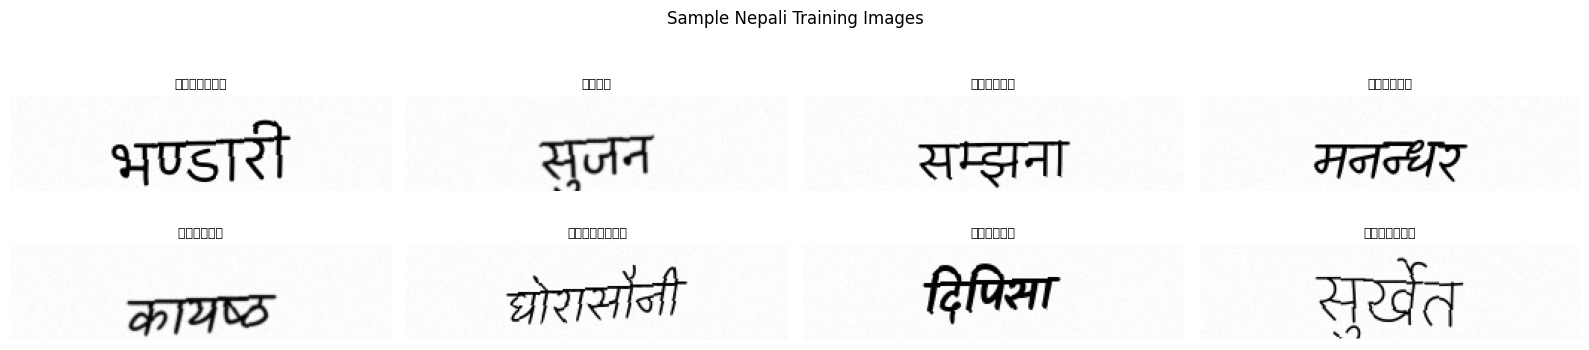

Labels:
  1. भण्डारी
  2. सुजन
  3. सम्झना
  4. मनन्धर
  5. कायष्‍ठ
  6. घोरासौनी
  7. दिपिसा
  8. सुर्खेत


In [9]:
# ── CELL 8: Preview a few training samples ───────────────────────
samples = random.sample(train_pairs, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 4))
for ax, (path, label) in zip(axes.flat, samples):
    try:
        img = Image.open(path).convert('L')
        ax.imshow(img, cmap='gray')
    except:
        ax.set_facecolor('red')
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Nepali Training Images')
plt.tight_layout()
plt.show()

print('Labels:')
for i, (_, label) in enumerate(samples, 1):
    print(f'  {i}. {label}')

In [10]:
# ── CELL 9: Define CRNN (same architecture as Phase 1) ───────────
# Must match Phase 1 exactly so checkpoint loads correctly

class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.cnn = vgg.features

        for i, layer in enumerate(self.cnn):
            if i < 14:
                for p in layer.parameters():
                    p.requires_grad = False
            else:
                for p in layer.parameters():
                    p.requires_grad = True

        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.rnn  = nn.LSTM(
            input_size    = 512,
            hidden_size   = hidden_size,
            num_layers    = 2,
            bidirectional = True,
            batch_first   = False,
            dropout       = 0.3
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        f = self.cnn(x)
        f = self.pool(f)
        b, c, h, w = f.size()
        f = f.squeeze(2)
        f = f.permute(2, 0, 1)
        r, _ = self.rnn(f)
        out = self.fc(r)
        return torch.nn.functional.log_softmax(out, dim=2)


# Build model with Phase 1 class count first to load weights
phase1_ckpt   = torch.load(PHASE1_MODEL, map_location=DEVICE)
phase1_vocab  = phase1_ckpt['vocab']
phase1_n      = phase1_ckpt['num_classes']

model = CRNN(num_classes=phase1_n).to(DEVICE)
model.load_state_dict(phase1_ckpt['model_state'])
print(f'Phase 1 checkpoint loaded — epoch {phase1_ckpt["epoch"]}  '
      f'val_acc={phase1_ckpt["val_acc"]*100:.2f}%')

# If vocab was extended, reinitialize FC layer for new class count
if VOCAB_EXTENDED:
    print(f'\nExtending FC: {phase1_n} → {NUM_CLASSES} classes')
    old_fc    = model.fc
    new_fc    = nn.Linear(old_fc.in_features, NUM_CLASSES)
    # Copy weights for existing classes — new classes get random init
    with torch.no_grad():
        new_fc.weight[:phase1_n] = old_fc.weight
        new_fc.bias[:phase1_n]   = old_fc.bias
    model.fc = new_fc.to(DEVICE)
    print('FC layer extended — existing class weights preserved.')
else:
    print('\nFC layer reused from Phase 1 (no new classes).')

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params     : {total:,}')
print(f'Trainable        : {trainable:,}')
print(f'Frozen (VGG b1-2): {total - trainable:,}')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 217MB/s]  


Phase 1 checkpoint loaded — epoch 34  val_acc=62.06%

Extending FC: 109 → 116 classes
FC layer extended — existing class weights preserved.

Total params     : 17,928,116
Trainable        : 16,782,708
Frozen (VGG b1-2): 1,145,408


In [12]:
# ── CELL 10: Loss, Optimizer, Scheduler ──────────────────────────
#
# CNN gets LR_CNN=1e-6 — very slow update, preserve Phase 1 features
# RNN/FC get LR_RNN=1e-4 — learn Nepali-specific sequence patterns
#
# We do NOT resume the Phase 1 optimizer state because:
# (a) LRs are different, (b) momentum buffers are stale from a different task

criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

optimizer = optim.Adam([
    {'params': [p for p in model.cnn.parameters() if p.requires_grad],
     'lr': LR_CNN},
    {'params': model.rnn.parameters(), 'lr': LR_RNN},
    {'params': model.fc.parameters(),  'lr': LR_FC},
])

# ReduceLROnPlateau — if val loss doesn't improve for 3 epochs, halve LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

print('Optimizer ready.')
print(f'  CNN LR  : {LR_CNN}')
print(f'  RNN LR  : {LR_RNN}')
print(f'  FC  LR  : {LR_FC}')

Optimizer ready.
  CNN LR  : 1e-06
  RNN LR  : 0.0001
  FC  LR  : 0.0001


In [13]:
# ── CELL 11: CTC Decoder + Metrics ───────────────────────────────

def ctc_decode(output, idx2char):
    preds = output.argmax(dim=2).permute(1, 0)  # [B, T]
    decoded = []
    for seq in preds:
        chars, prev = [], None
        for idx in seq.tolist():
            if idx != prev and idx != 0:
                chars.append(idx2char.get(idx, ''))
            prev = idx
        decoded.append(''.join(chars))
    return decoded

def word_accuracy(preds, targets):
    return sum(p == t for p, t in zip(preds, targets)) / len(targets)

def char_error_rate(preds, targets):
    total, errors = 0, 0
    for p, t in zip(preds, targets):
        total  += len(t)
        errors += sum(1 for a, b in zip(p.ljust(len(t)), t) if a != b)
        errors += abs(len(p) - len(t))
    return errors / max(total, 1)

print('Decoder and metrics ready.')

Decoder and metrics ready.


In [15]:
# ── CELL 12: Training + Validation Functions ─────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, (imgs, labels, lengths) in enumerate(loader):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        T, B = out.size(0), out.size(1)
        input_lens = torch.full((B,), T, dtype=torch.long)
        flat = []
        for j in range(B):
            flat.extend(labels[j][:lengths[j].item()].tolist())
        flat = torch.tensor(flat, dtype=torch.long)
        loss = criterion(out, flat, input_lens, lengths)
        if not (torch.isnan(loss) or torch.isinf(loss)):
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f'    Batch {i+1}/{len(loader)}  loss={loss.item():.4f}')
    return total_loss / len(loader)


def validate_epoch(model, loader, criterion, idx2char, device, n_show=5):
    model.eval()
    total_loss, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for imgs, labels, lengths in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            T, B = out.size(0), out.size(1)
            input_lens = torch.full((B,), T, dtype=torch.long)
            flat, words = [], []
            for j in range(B):
                l = lengths[j].item()
                flat.extend(labels[j][:l].tolist())
                words.append(''.join(idx2char.get(labels[j][k].item(), '')
                                     for k in range(l)))
            flat = torch.tensor(flat, dtype=torch.long)
            loss = criterion(out, flat, input_lens, lengths)
            if not torch.isnan(loss):
                total_loss += loss.item()
            all_preds.extend(ctc_decode(out, idx2char))
            all_targets.extend(words)

    acc = word_accuracy(all_preds, all_targets)
    cer = char_error_rate(all_preds, all_targets)

    print(f'  Sample predictions (first {n_show}):')
    for p, t in zip(all_preds[:n_show], all_targets[:n_show]):
        mark = '✓' if p == t else '✗'
        print(f'    {mark}  true={t}  pred={p}')

    return total_loss / len(loader), acc, cer

print('Training functions ready.')

Training functions ready.


In [16]:
# ── CELL 13: FINE-TUNING LOOP ─────────────────────────────────────
# 10 epochs. Checkpoint saved every epoch.
# Expected time: ~20-40 min on T4 GPU (dataset is ~400k images).

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_cer': []}
best_acc   = 0.0
best_epoch = 0

print('=' * 55)
print(' PHASE 2 FINE-TUNING START')
print(f' Epochs     : {EPOCHS}')
print(f' Train imgs : {len(train_ds)}')
print(f' Val imgs   : {len(val_ds)}')
print(f' Batch size : {BATCH_SIZE}')
print(f' Device     : {DEVICE}')
print(f' CNN LR     : {LR_CNN}  (low — preserve Phase 1 features)')
print(f' RNN/FC LR  : {LR_RNN}')
print(f' Checkpoint : every epoch → {CKPT_DIR}')
print('=' * 55)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n── Epoch {epoch}/{EPOCHS} ──────────────────────────────')

    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_cer = validate_epoch(
        model, val_loader, criterion, idx2char, DEVICE
    )
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_cer'].append(val_cer)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[1]['lr']  # RNN lr

    print(f'  train_loss : {train_loss:.4f}')
    print(f'  val_loss   : {val_loss:.4f}')
    print(f'  val_acc    : {val_acc*100:.2f}%')
    print(f'  val_cer    : {val_cer:.4f}')
    print(f'  lr (rnn)   : {lr_now:.2e}')
    print(f'  time       : {elapsed:.0f}s')

    # Save best model
    if val_acc > best_acc:
        best_acc   = val_acc
        best_epoch = epoch
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_acc'     : val_acc,
            'val_cer'     : val_cer,
            'num_classes' : NUM_CLASSES,
            'vocab'       : vocab,
            'history'     : history,
        }, MODEL_PATH)
        print(f'  ★ BEST saved  epoch={epoch}  acc={val_acc*100:.2f}%')

    # Save checkpoint every epoch regardless
    ckpt_name = CKPT_DIR / f'p2_epoch{epoch:02d}_acc{val_acc*100:.1f}.pth'
    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'history'     : history,
        'num_classes' : NUM_CLASSES,
        'vocab'       : vocab,
    }, ckpt_name)
    print(f'  ✓ Checkpoint → {ckpt_name.name}')

print(f'\n{"="*55}')
print(f' FINE-TUNING COMPLETE')
print(f' Best val_acc : {best_acc*100:.2f}% at epoch {best_epoch}')
print(f' Best model   : {MODEL_PATH}')
print(f'{"="*55}')

 PHASE 2 FINE-TUNING START
 Epochs     : 20
 Train imgs : 20772
 Val imgs   : 3672
 Batch size : 64
 Device     : cuda
 CNN LR     : 1e-06  (low — preserve Phase 1 features)
 RNN/FC LR  : 0.0001
 Checkpoint : every epoch → /kaggle/working/checkpoints_phase2

── Epoch 1/20 ──────────────────────────────
    Batch 100/325  loss=2.6501
    Batch 200/325  loss=1.5533
    Batch 300/325  loss=1.7281
  Sample predictions (first 5):
    ✗  true=आगत  pred=आगन
    ✗  true=आगत  pred=आवत
    ✗  true=आगत  pred=अवत
    ✗  true=आगत  pred=आगव
    ✓  true=आगत  pred=आगत
  train_loss : 2.0744
  val_loss   : 1.4338
  val_acc    : 19.61%
  val_cer    : 0.6135
  lr (rnn)   : 1.00e-04
  time       : 117s
  ★ BEST saved  epoch=1  acc=19.61%
  ✓ Checkpoint → p2_epoch01_acc19.6.pth

── Epoch 2/20 ──────────────────────────────
    Batch 100/325  loss=1.4877
    Batch 200/325  loss=1.2525
    Batch 300/325  loss=1.2687
  Sample predictions (first 5):
    ✓  true=आगत  pred=आगत
    ✗  true=आगत  pred=आवत
    ✗  tru

In [17]:
# ── CELL 13b: CONTINUE TRAINING (PROGRESSIVE UNFREEZING + EARLY STOPPING) ──
# This cell loads the best checkpoint from the Phase 2a run, then continues
# training with a gradual unfreezing schedule and early stopping.

import re
import time
from pathlib import Path

# ---------- Configuration (adjust as needed) ----------
CONTINUE_EPOCHS = 20          # number of additional epochs to train
PATIENCE = 5                  # early stopping patience (based on val_loss)
# Unfreeze schedule: (relative_epoch, list_of_layer_indices, learning_rate_for_those_layers)
UNFREEZE_SCHEDULE = [
    (5, list(range(10, 14)), 1e-6),   # after 5 more epochs → unfreeze indices 10‑13 (Block 3 conv1/2)
    (10, list(range(5, 10)), 1e-6),   # after 10 more epochs → unfreeze indices 5‑9 (Block 2)
    (15, list(range(0, 5)), 1e-7),    # after 15 more epochs → unfreeze indices 0‑4 (Block 1)
]
# Note: The learning rates here are not used directly; we use the same LR_CNN for all CNN parameters.
# You can modify build_optimizer() to assign separate LRs per group if needed.

# ---------- Helper: find the best checkpoint by validation accuracy ----------
def find_best_checkpoint(ckpt_dir):
    """Return the path to the checkpoint with the highest val_acc."""
    ckpt_files = list(ckpt_dir.glob('p2_epoch*.pth'))
    if not ckpt_files:
        raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")
    best_path = None
    best_acc = -1.0
    for f in ckpt_files:
        match = re.search(r'acc([\d.]+)\.pth$', f.name)
        if match:
            acc = float(match.group(1))
            if acc > best_acc:
                best_acc = acc
                best_path = f
    if best_path is None:
        # fallback: pick the latest by epoch number
        best_path = sorted(ckpt_files, key=lambda x: int(re.search(r'epoch(\d+)', x.name).group(1)))[-1]
    return best_path

best_ckpt_path = find_best_checkpoint(CKPT_DIR)
print(f"✅ Loading best checkpoint: {best_ckpt_path.name}")

# ---------- Load checkpoint ----------
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])

# Load optimizer state if present; otherwise reinitialize
if 'optimizer' in ckpt:
    optimizer.load_state_dict(ckpt['optimizer'])
    print("Optimizer state restored from checkpoint.")
else:
    print("Optimizer state not found; reinitializing with current LR settings.")
    optimizer = optim.Adam([
        {'params': [p for p in model.cnn.parameters() if p.requires_grad], 'lr': LR_CNN},
        {'params': model.rnn.parameters(), 'lr': LR_RNN},
        {'params': model.fc.parameters(),  'lr': LR_FC},
    ])

# Load history if present, otherwise start fresh
history = ckpt.get('history', {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_cer': []})

start_epoch = ckpt.get('epoch', 0)
start_val_acc = ckpt.get('val_acc', 0.0)
print(f"Resuming from epoch {start_epoch} with val_acc = {start_val_acc*100:.2f}%")

# ---------- Helper: rebuild optimizer after unfreezing ----------
def build_optimizer(model):
    """Create an Adam optimizer with separate groups for CNN (trainable), RNN, and FC."""
    trainable_cnn = [p for p in model.cnn.parameters() if p.requires_grad]
    return optim.Adam([
        {'params': trainable_cnn, 'lr': LR_CNN},
        {'params': model.rnn.parameters(), 'lr': LR_RNN},
        {'params': model.fc.parameters(),  'lr': LR_FC},
    ])

# Rebuild optimizer to ensure it matches the current trainable parameters
optimizer = build_optimizer(model)

# Scheduler (ReduceLROnPlateau) – will monitor val_loss and reduce LR if plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

# ---------- Training loop with progressive unfreezing ----------
print("\n" + "="*60)
print(" PHASE 2b: CONTINUED TRAINING WITH PROGRESSIVE UNFREEZING")
print(f" Starting from epoch {start_epoch}")
print(f" Additional epochs: {CONTINUE_EPOCHS}")
print(f" Early stopping patience: {PATIENCE} (based on val_loss)")
print(" Unfreeze schedule (relative to this run):")
for rel_epoch, idxs, lr in UNFREEZE_SCHEDULE:
    print(f"   After {rel_epoch} more epochs: unfreeze layers {idxs} (LR = {lr})")
print("="*60)

best_acc = start_val_acc
best_epoch = start_epoch
early_stop_counter = 0
unfrozen_indices = set()   # track which layer indices have been unfrozen

for rel_epoch in range(1, CONTINUE_EPOCHS + 1):
    current_epoch = start_epoch + rel_epoch
    t0 = time.time()
    print(f"\n── Epoch {current_epoch} (relative {rel_epoch}/{CONTINUE_EPOCHS}) ──────────────────────────────")

    # ----- Check if we need to unfreeze any layers -----
    for schedule_epoch, idxs, lr in UNFREEZE_SCHEDULE:
        if rel_epoch == schedule_epoch:
            for idx in idxs:
                if idx not in unfrozen_indices:
                    layer = model.cnn[idx]
                    for p in layer.parameters():
                        p.requires_grad = True
                    unfrozen_indices.add(idx)
            # Rebuild optimizer to include the newly trainable parameters
            optimizer = build_optimizer(model)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, patience=3, factor=0.5
            )
            print(f"  *** Unfroze layers {idxs} (CNN LR = {LR_CNN}) ***")

    # ----- Train one epoch -----
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_cer = validate_epoch(
        model, val_loader, criterion, idx2char, DEVICE
    )
    scheduler.step(val_loss)   # adjust LR based on val_loss

    # Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_cer'].append(val_cer)

    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]['lr']   # current CNN learning rate

    print(f"  train_loss : {train_loss:.4f}")
    print(f"  val_loss   : {val_loss:.4f}")
    print(f"  val_acc    : {val_acc*100:.2f}%")
    print(f"  val_cer    : {val_cer:.4f}")
    print(f"  lr (cnn)   : {lr_now:.2e}")
    print(f"  time       : {elapsed:.0f}s")

    # ----- Save checkpoint every epoch -----
    ckpt_name = CKPT_DIR / f'p2b_epoch{current_epoch:03d}_acc{val_acc*100:.1f}.pth'
    torch.save({
        'epoch'       : current_epoch,
        'model_state' : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'history'     : history,
        'num_classes' : NUM_CLASSES,
        'vocab'       : vocab,
        'val_acc'     : val_acc,
        'val_cer'     : val_cer,
    }, ckpt_name)
    print(f"  ✓ Checkpoint → {ckpt_name.name}")

    # ----- Save best model -----
    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = current_epoch
        torch.save({
            'epoch'       : current_epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_acc'     : val_acc,
            'val_cer'     : val_cer,
            'num_classes' : NUM_CLASSES,
            'vocab'       : vocab,
            'history'     : history,
        }, OUTPUT_DIR / 'crnn_nepali_best_phase2b.pth')
        print(f"  ★ BEST saved  epoch={current_epoch}  acc={val_acc*100:.2f}%")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"  No improvement; patience {early_stop_counter}/{PATIENCE}")

    # ----- Early stopping -----
    if early_stop_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping triggered after {PATIENCE} epochs without improvement in val_loss.")
        break

print(f"\n{'='*60}")
print(f" PHASE 2b TRAINING COMPLETE")
print(f" Best val_acc : {best_acc*100:.2f}% at epoch {best_epoch}")
print(f" Best model   : {OUTPUT_DIR / 'crnn_nepali_best_phase2b.pth'}")
print("="*60)

✅ Loading best checkpoint: p2_epoch19_acc49.1.pth
Optimizer state restored from checkpoint.
Resuming from epoch 19 with val_acc = 0.00%

 PHASE 2b: CONTINUED TRAINING WITH PROGRESSIVE UNFREEZING
 Starting from epoch 19
 Additional epochs: 20
 Early stopping patience: 5 (based on val_loss)
 Unfreeze schedule (relative to this run):
   After 5 more epochs: unfreeze layers [10, 11, 12, 13] (LR = 1e-06)
   After 10 more epochs: unfreeze layers [5, 6, 7, 8, 9] (LR = 1e-06)
   After 15 more epochs: unfreeze layers [0, 1, 2, 3, 4] (LR = 1e-07)

── Epoch 20 (relative 1/20) ──────────────────────────────
    Batch 100/325  loss=0.1420
    Batch 200/325  loss=0.0934
    Batch 300/325  loss=0.1642
  Sample predictions (first 5):
    ✓  true=आगत  pred=आगत
    ✗  true=आगत  pred=आजत
    ✗  true=आगत  pred=आयत
    ✓  true=आगत  pred=आगत
    ✓  true=आगत  pred=आगत
  train_loss : 0.1352
  val_loss   : 0.5357
  val_acc    : 48.88%
  val_cer    : 0.3505
  lr (cnn)   : 1.00e-06
  time       : 67s
  ✓ Checkpo

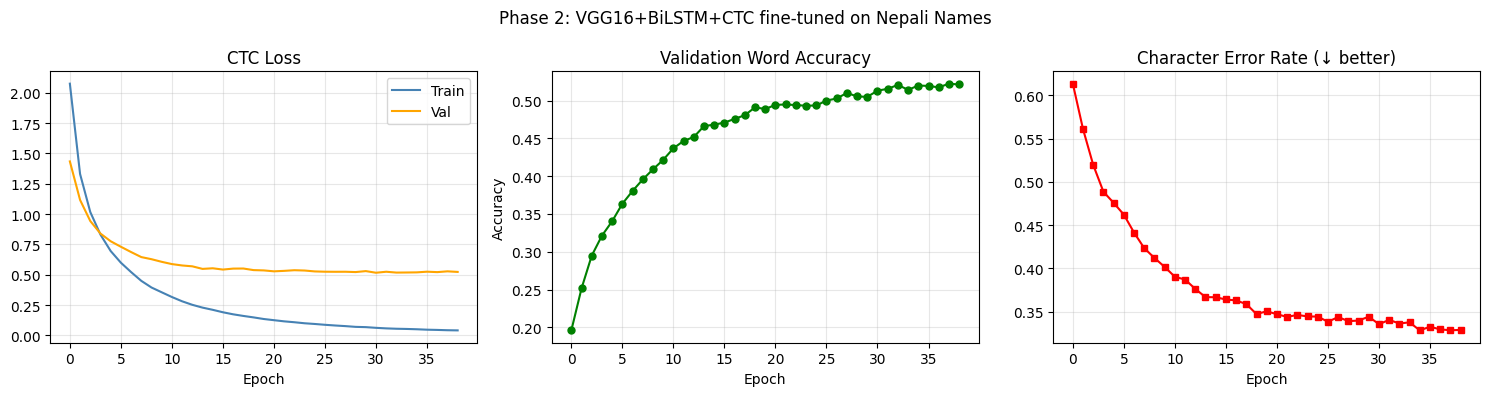

Saved: phase2_curves.png


In [18]:
# ── CELL 14: Plot Training Curves ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='orange')
axes[0].set_title('CTC Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], color='green', marker='o', ms=5)
axes[1].set_title('Validation Word Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_cer'], color='red', marker='s', ms=5)
axes[2].set_title('Character Error Rate (↓ better)')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.suptitle('Phase 2: VGG16+BiLSTM+CTC fine-tuned on Nepali Names')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase2_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase2_curves.png')

✅ Loaded Phase 2b best model — epoch 38  val_acc=52.23%


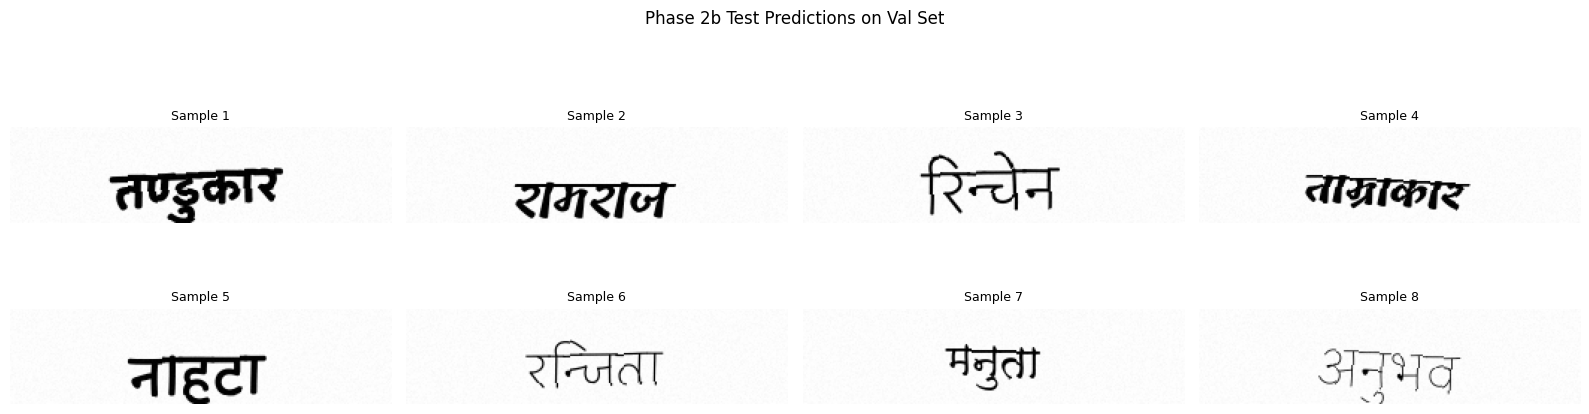


#    | Actual               | Predicted            | Status
1    | तण्डुकार             | तण्ढुकार             | ✗ Mismatch
2    | रामराज               | रामराज               | ✓ Match
3    | रिन्चेन              | रिचेन                | ✗ Mismatch
4    | ताम्राकार            | ताम्पकार             | ✗ Mismatch
5    | नाहटा                | नाहटा                | ✓ Match
6    | रन्जिता              | रन्जिता              | ✓ Match
7    | मनुता                | मनुता                | ✓ Match
8    | अनुभव                | अनुषत                | ✗ Mismatch


In [19]:
#(updated) ── CELL 15: Test Predictions on Val Samples (UPDATED for Phase 2b) ─────

# Load the BEST model from Phase 2b (52.23% accuracy at epoch 38)
BEST_MODEL_PHASE2B = OUTPUT_DIR / 'crnn_nepali_best_phase2b.pth'

if BEST_MODEL_PHASE2B.exists():
    ckpt = torch.load(BEST_MODEL_PHASE2B, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'✅ Loaded Phase 2b best model — epoch {ckpt["epoch"]}  '
          f'val_acc={ckpt["val_acc"]*100:.2f}%')
else:
    # Fallback to the original Phase 2a best model if Phase 2b model is missing
    print(f"⚠️ Phase 2b model not found at {BEST_MODEL_PHASE2B}")
    print("Falling back to Phase 2a best model.")
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'Loaded Phase 2a best model — epoch {ckpt["epoch"]}  '
          f'val_acc={ckpt["val_acc"]*100:.2f}%')

tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

samples = random.sample(val_pairs, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 5))

results = []
with torch.no_grad():
    for i, (ax, (path, true_label)) in enumerate(zip(axes.flat, samples), 1):
        img    = Image.open(path).convert('RGB')
        tensor = tf(img).unsqueeze(0).to(DEVICE)
        out    = model(tensor)
        pred   = ctc_decode(out, idx2char)[0]
        is_correct = (pred == true_label)
        results.append((i, true_label, pred, '✓ Match' if is_correct else '✗ Mismatch'))
        ax.imshow(Image.open(path).convert('L'), cmap='gray')
        ax.set_title(f'Sample {i}', fontsize=9)
        ax.axis('off')

plt.suptitle('Phase 2b Test Predictions on Val Set')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase2b_test_preds.png', dpi=150)
plt.show()

print()
print('=' * 52)
print(f'{"#":<4} | {"Actual":<20} | {"Predicted":<20} | Status')
print('=' * 52)
for idx, actual, predicted, status in results:
    print(f'{idx:<4} | {actual:<20} | {predicted:<20} | {status}')
print('=' * 52)

In [ ]:
# ── CELL 15: Test Predictions on Val Samples ─────────────────────

# Load best checkpoint
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best model — epoch {ckpt["epoch"]}  '
      f'val_acc={ckpt["val_acc"]*100:.2f}%')

tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

samples = random.sample(val_pairs, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 5))

results = []
with torch.no_grad():
    for i, (ax, (path, true_label)) in enumerate(zip(axes.flat, samples), 1):
        img    = Image.open(path).convert('RGB')
        tensor = tf(img).unsqueeze(0).to(DEVICE)
        out    = model(tensor)
        pred   = ctc_decode(out, idx2char)[0]
        is_correct = (pred == true_label)
        results.append((i, true_label, pred, '✓ Match' if is_correct else '✗ Mismatch'))
        ax.imshow(Image.open(path).convert('L'), cmap='gray')
        ax.set_title(f'Sample {i}', fontsize=9)
        ax.axis('off')

plt.suptitle('Phase 2 Test Predictions on Val Set')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase2_test_preds.png', dpi=150)
plt.show()

print()
print('=' * 52)
print(f'{"#":<4} | {"Actual":<20} | {"Predicted":<20} | Status')
print('=' * 52)
for idx, actual, predicted, status in results:
    print(f'{idx:<4} | {actual:<20} | {predicted:<20} | {status}')
print('=' * 52)

In [20]:
# ── CELL 16: Gradio UI for manual testing ────────────────────────
# Lets you drag-and-drop any image and see the model's prediction.
# Runs inside the Kaggle session — no iPhone needed.
#
# If gradio is not installed: !pip install gradio -q

try:
    import gradio as gr
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'gradio', '-q'])
    import gradio as gr

model.eval()

infer_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

def predict(pil_image):
    if pil_image is None:
        return 'No image provided.'
    try:
        img    = pil_image.convert('RGB')
        tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out  = model(tensor)
            pred = ctc_decode(out, idx2char)[0]
        return pred if pred else '(empty prediction)'
    except Exception as e:
        return f'Error: {e}'

demo = gr.Interface(
    fn      = predict,
    inputs  = gr.Image(type='pil', label='Upload a Devanagari word image'),
    outputs = gr.Textbox(label='Predicted text'),
    title   = 'Nepali OCR — CRNN Phase 2',
    description = 'Upload a cropped Devanagari word image. Model predicts the text.'
)

demo.launch(share=True)  # share=True gives a public link valid for 72 hours

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b81cd90ce5e2bef4ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ── (updated)CELL 16: Gradio UI (load any model) ──────────────────────────────

# --- Set this to the model you want to use ---
# CHECKPOINT_TO_LOAD = OUTPUT_DIR / 'crnn_nepali_best.pth'   # Phase 2a (49.10%)
# CHECKPOINT_TO_LOAD = OUTPUT_DIR / 'crnn_nepali_best_phase2b.pth'   # Phase 2b (52.23%)
# Or any other checkpoint, e.g. a specific epoch:
CHECKPOINT_TO_LOAD = CKPT_DIR / 'p2_epoch19_acc49.1.pth'
# CHECKPOINT_TO_LOAD = CKPT_DIR / 'p2b_epoch025_acc49.3.pth'

# --- Load the chosen checkpoint ---
if not CHECKPOINT_TO_LOAD.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_TO_LOAD}")

ckpt = torch.load(CHECKPOINT_TO_LOAD, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"✅ Loaded model from: {CHECKPOINT_TO_LOAD.name}")
print(f"   Epoch: {ckpt.get('epoch', 'N/A')}  |  Val Acc: {ckpt.get('val_acc', 0)*100:.2f}%")

# --- Gradio setup (unchanged) ---
try:
    import gradio as gr
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'gradio', '-q'])
    import gradio as gr

infer_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict(pil_image):
    if pil_image is None:
        return 'No image provided.'
    try:
        img = pil_image.convert('RGB')
        tensor = infer_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = model(tensor)
            pred = ctc_decode(out, idx2char)[0]
        return pred if pred else '(empty prediction)'
    except Exception as e:
        return f'Error: {e}'

demo = gr.Interface(
    fn      = predict,
    inputs  = gr.Image(type='pil', label='Upload a Devanagari word image'),
    outputs = gr.Textbox(label='Predicted text'),
    title   = f'Nepali OCR — {CHECKPOINT_TO_LOAD.stem}',
    description = f'Using model: {CHECKPOINT_TO_LOAD.name}'
)

demo.launch(share=True)

In [31]:
# ── CELL 17: Files to download ────────────────────────────────────
import os
print('Files to download from Kaggle Output panel:')
for f in [MODEL_PATH, VOCAB2_PATH,
          OUTPUT_DIR/'phase2_curves.png',
          OUTPUT_DIR/'phase2_test_preds.png']:
    if Path(f).exists():
        size = os.path.getsize(f) / 1e6
        print(f'  ✓  {Path(f).name}  ({size:.1f} MB)')
    else:
        print(f'  ✗  {Path(f).name}  NOT FOUND')

print()
print('Checkpoints (one per epoch):')
for ckpt in sorted(CKPT_DIR.glob('*.pth')):
    size = os.path.getsize(ckpt) / 1e6
    print(f'  {ckpt.name}  ({size:.1f} MB)')

Files to download from Kaggle Output panel:
  ✓  crnn_nepali_best.pth  (206.0 MB)
  ✓  vocab_phase2.txt  (0.0 MB)
  ✓  phase2_curves.png  (0.1 MB)
  ✗  phase2_test_preds.png  NOT FOUND

Checkpoints (one per epoch):
  p2_epoch01_acc19.6.pth  (206.0 MB)
  p2_epoch02_acc25.2.pth  (206.0 MB)
  p2_epoch03_acc29.5.pth  (206.0 MB)
  p2_epoch04_acc32.1.pth  (206.0 MB)
  p2_epoch05_acc34.0.pth  (206.0 MB)
  p2_epoch06_acc36.4.pth  (206.0 MB)
  p2_epoch07_acc38.0.pth  (206.0 MB)
  p2_epoch08_acc39.6.pth  (206.0 MB)
  p2_epoch09_acc40.9.pth  (206.0 MB)
  p2_epoch10_acc42.2.pth  (206.0 MB)
  p2_epoch11_acc43.7.pth  (206.0 MB)
  p2_epoch12_acc44.7.pth  (206.0 MB)
  p2_epoch13_acc45.2.pth  (206.0 MB)
  p2_epoch14_acc46.6.pth  (206.0 MB)
  p2_epoch15_acc46.8.pth  (206.0 MB)
  p2_epoch16_acc47.1.pth  (206.0 MB)
  p2_epoch17_acc47.6.pth  (206.0 MB)
  p2_epoch18_acc48.1.pth  (206.0 MB)
  p2_epoch19_acc49.1.pth  (206.0 MB)
  p2_epoch20_acc48.6.pth  (206.0 MB)
  p2b_epoch020_acc48.9.pth  (206.0 MB)
  p2b_

In [1]:
# ── CELL 17: Files to download (filtered to keep only key checkpoints) ──
import os
import re

print('Files to download from Kaggle Output panel:')

# Essential files (always show)
essential_files = [
    MODEL_PATH,
    VOCAB2_PATH,
    OUTPUT_DIR / 'phase2_curves.png',
    OUTPUT_DIR / 'phase2_test_preds.png',
]

for f in essential_files:
    if Path(f).exists():
        size = os.path.getsize(f) / 1e6
        print(f'  ✓  {Path(f).name}  ({size:.1f} MB)')
    else:
        print(f'  ✗  {Path(f).name}  NOT FOUND')

# Filter checkpoints: keep only epochs 5, 10, 15, 20
desired_epochs = {5, 10, 15, 20}
print()
print('Checkpoints (filtered – epochs 5,10,15,20 and best model):')
all_ckpts = sorted(CKPT_DIR.glob('*.pth'))

for ckpt in all_ckpts:
    # Extract epoch number from filename (e.g., "p2_epoch05_acc19.6.pth")
    match = re.search(r'p2_epoch(\d+)_', ckpt.name)
    if match:
        epoch = int(match.group(1))
        if epoch in desired_epochs:
            size = os.path.getsize(ckpt) / 1e6
            print(f'  {ckpt.name}  ({size:.1f} MB)')
    else:
        # Fallback: include if not matching pattern (e.g., best model already shown separately)
        pass

# Also explicitly show the best model from Phase 2a (it may be in /kaggle/working)
if Path(MODEL_PATH).exists():
    size = os.path.getsize(MODEL_PATH) / 1e6
    print(f'  {MODEL_PATH.name} (best)  ({size:.1f} MB)')

Files to download from Kaggle Output panel:


NameError: name 'MODEL_PATH' is not defined

In [6]:
# ── CELL 17b: Download buttons for selected checkpoints ────────────
from IPython.display import display, HTML
from pathlib import Path
import os

# --- Define paths in case they weren't set earlier ---
if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = Path('/kaggle/working')
if 'CKPT_DIR' not in globals():
    CKPT_DIR = OUTPUT_DIR / 'checkpoints_phase2'
if 'VOCAB2_PATH' not in globals():
    VOCAB2_PATH = OUTPUT_DIR / 'vocab_phase2.txt'

# Ensure they are Path objects
if isinstance(OUTPUT_DIR, str):
    OUTPUT_DIR = Path(OUTPUT_DIR)
if isinstance(CKPT_DIR, str):
    CKPT_DIR = Path(CKPT_DIR)
if isinstance(VOCAB2_PATH, str):
    VOCAB2_PATH = Path(VOCAB2_PATH)

# --- Files to download (edit this list as needed) ---
files_to_download = [
    # Selected checkpoints: epochs 5, 10, 15, 20
    CKPT_DIR / 'p2_epoch05_acc34.0.pth',
    CKPT_DIR / 'p2_epoch10_acc42.2.pth',
    CKPT_DIR / 'p2_epoch15_acc46.8.pth',
    CKPT_DIR / 'p2_epoch20_acc48.6.pth',
    
    # Best Phase 2a model (49.10%)
    OUTPUT_DIR / 'crnn_nepali_best.pth',
    
    # Optional useful files
    VOCAB2_PATH,
    OUTPUT_DIR / 'phase2_curves.png',
    OUTPUT_DIR / 'phase2_test_preds.png',
]

# --- Generate clickable HTML links ---
html = '<div style="font-family: -apple-system, BlinkMacSystemFont, sans-serif; line-height: 2.2;">'
html += '<h3>📥 Click a file name to download it:</h3>'
html += '<ul style="list-style: none; padding: 0;">'

for f in files_to_download:
    if not isinstance(f, Path):
        f = Path(f)
    if f.exists():
        size = os.path.getsize(f) / 1e6
        html += f'''
        <li style="padding: 4px 0;">
            🔹 <a href="{f}" download style="text-decoration: none; color: #0366d6; font-weight: 500;">
                {f.name}
            </a>
            <span style="color: #586069; font-size: 0.9em;">({size:.1f} MB)</span>
        </li>
        '''
    else:
        html += f'<li>❌ <span style="color: #d73a49;">{f.name} (not found)</span></li>'

html += '</ul></div>'

display(HTML(html))

In [7]:
# ── Show all Phase 2 checkpoints with sizes ──
import os
from pathlib import Path

CKPT_DIR = Path('/kaggle/working/checkpoints_phase2')
OUTPUT_DIR = Path('/kaggle/working')

print("📁 Checkpoints in /kaggle/working/checkpoints_phase2:")
for f in sorted(CKPT_DIR.glob('*.pth')):
    size = os.path.getsize(f) / 1e6
    print(f"  {f.name}  ({size:.1f} MB)")

print("\n📁 Other important files in /kaggle/working:")
for f in ['crnn_nepali_best.pth', 'vocab_phase2.txt', 'phase2_curves.png', 'phase2_test_preds.png']:
    f_path = OUTPUT_DIR / f
    if f_path.exists():
        size = os.path.getsize(f_path) / 1e6
        print(f"  {f}  ({size:.1f} MB)")
    else:
        print(f"  {f}  (not found)")

📁 Checkpoints in /kaggle/working/checkpoints_phase2:
  p2_epoch01_acc19.6.pth  (206.0 MB)
  p2_epoch02_acc25.2.pth  (206.0 MB)
  p2_epoch03_acc29.5.pth  (206.0 MB)
  p2_epoch04_acc32.1.pth  (206.0 MB)
  p2_epoch05_acc34.0.pth  (206.0 MB)
  p2_epoch06_acc36.4.pth  (206.0 MB)
  p2_epoch07_acc38.0.pth  (206.0 MB)
  p2_epoch08_acc39.6.pth  (206.0 MB)
  p2_epoch09_acc40.9.pth  (206.0 MB)
  p2_epoch10_acc42.2.pth  (206.0 MB)
  p2_epoch11_acc43.7.pth  (206.0 MB)
  p2_epoch12_acc44.7.pth  (206.0 MB)
  p2_epoch13_acc45.2.pth  (206.0 MB)
  p2_epoch14_acc46.6.pth  (206.0 MB)
  p2_epoch15_acc46.8.pth  (206.0 MB)
  p2_epoch16_acc47.1.pth  (206.0 MB)
  p2_epoch17_acc47.6.pth  (206.0 MB)
  p2_epoch18_acc48.1.pth  (206.0 MB)
  p2_epoch19_acc49.1.pth  (206.0 MB)
  p2_epoch20_acc48.6.pth  (206.0 MB)
  p2b_epoch020_acc48.9.pth  (206.0 MB)
  p2b_epoch021_acc49.4.pth  (206.0 MB)
  p2b_epoch022_acc49.5.pth  (206.0 MB)
  p2b_epoch023_acc49.4.pth  (206.0 MB)
  p2b_epoch024_acc49.3.pth  (213.1 MB)
  p2b_epoch0